In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seed untuk keandalan hasil data
np.random.seed(42)
n_samples = 150

id_pengujian = [f'TEST-{3000+i}' for i in range(n_samples)]
tgl_uji = pd.date_range(start='2024-02-01', periods=n_samples, freq='D')
id_sensor = np.random.choice(['SNS-A1', 'SNS-B2', 'SNS-C3', 'SNS-D4'], size=n_samples)
kategori = np.random.choice(['Resistor', 'Kapasitor', 'Induktor', 'Transistor'], size=n_samples)

suhu = np.random.normal(loc=25, scale=5, size=n_samples).round(1)
kelembaban = np.random.uniform(40, 85, size=n_samples).round(1)
tegangan = np.random.uniform(4.8, 5.2, size=n_samples).round(2)
arus = np.random.uniform(10, 50, size=n_samples).round(1)

# Membuat DataFrame
df = pd.DataFrame({
    'ID_Pengujian': id_pengujian,
    'Tanggal_Uji': tgl_uji,
    'ID_Sensor': id_sensor,
    'Kategori_Komponen': kategori,
    'Suhu_Celcius': suhu,
    'Kelembaban_Persen': kelembaban,
    'Tegangan_Volt': tegangan,
    'Arus_mA': arus
})

# Menyisipkan nilai outlier/kotor dan missing value secara terkontrol
df.loc[[5, 20, 50], 'Suhu_Celcius'] = -99.0  # Kode error sensor / outlier tidak logis
df.loc[[12, 45, 88, 105, 130], 'Tegangan_Volt'] = np.nan  # Missing values

# Simpan ke CSV lokal
df.to_csv('sensor_kualitas_elektronik.csv', index=False)

# Tampilkan ukuran data dan 10 baris pertama
print("Dimensi Data (Baris, Kolom):", df.shape)
df.head(10)

Dimensi Data (Baris, Kolom): (150, 8)


,ID_Pengujian,Tanggal_Uji,ID_Sensor,Kategori_Komponen,Suhu_Celcius,Kelembaban_Persen,Tegangan_Volt,Arus_mA
0,TEST-3000,2024-02-01,SNS-C3,Induktor,24.0,47.8,4.91,18.5
1,TEST-3001,2024-02-02,SNS-D4,Induktor,26.5,59.5,4.88,23.1
2,TEST-3002,2024-02-03,SNS-A1,Resistor,24.8,57.9,4.99,14.8
3,TEST-3003,2024-02-04,SNS-C3,Induktor,19.2,67.7,4.94,45.6
4,TEST-3004,2024-02-05,SNS-C3,Resistor,30.7,68.6,5.03,33.7
5,TEST-3005,2024-02-06,SNS-D4,Kapasitor,-99.0,42.0,4.83,37.2
6,TEST-3006,2024-02-07,SNS-A1,Induktor,29.0,56.9,5.19,41.6
7,TEST-3007,2024-02-08,SNS-A1,Kapasitor,20.5,68.2,5.19,29.9
8,TEST-3008,2024-02-09,SNS-C3,Resistor,32.0,62.6,5.08,13.5
9,TEST-3009,2024-02-10,SNS-B2,Transistor,18.0,78.5,5.01,31.5


In [2]:
# 1. Identifikasi awal data kotor (-99.0 pada Suhu dan NaN pada Tegangan)
print("=== SEBELUM PERBAIKAN ===")
print("Jumlah Suhu tidak logis (-99.0):", (df['Suhu_Celcius'] == -99.0).sum())
print("Jumlah Missing Value Tegangan  :", df['Tegangan_Volt'].isnull().sum())

# 2. Penanganan Suhu tidak logis (-99.0 diubah ke NaN lalu diimputasi dengan Median suhu valid)
df['Suhu_Celcius'] = df['Suhu_Celcius'].replace(-99.0, np.nan)
df['Suhu_Celcius'] = df['Suhu_Celcius'].fillna(df['Suhu_Celcius'].median())

# 3. Penanganan Missing Value pada Tegangan Volt (Imputasi Median)
df['Tegangan_Volt'] = df['Tegangan_Volt'].fillna(df['Tegangan_Volt'].median())

# Verifikasi hasil perbaikan
print("\n=== SETELAH PERBAIKAN ===")
print("Sisa Suhu < 0 °C             :", (df['Suhu_Celcius'] < 0).sum())
print("Sisa Missing Value Tegangan  :", df['Tegangan_Volt'].isnull().sum())

=== SEBELUM PERBAIKAN ===
Jumlah Suhu tidak logis (-99.0): 3
Jumlah Missing Value Tegangan  : 5

=== SETELAH PERBAIKAN ===
Sisa Suhu < 0 °C             : 0
Sisa Missing Value Tegangan  : 0


Justifikasi Penanganan Kualitas Data Sensor:

Nilai Suhu -99.0 °C: Nilai ini diidentifikasi sebagai kode error sistem pemantauan sensor (flag error), bukan merupakan hasil pengukuran riil yang valid. Nilai tersebut diganti menjadi NaN kemudian diimputasi menggunakan nilai median dari pembacaan suhu valid untuk mempertahankan integritas sampel pengujian.

Missing Value Tegangan Volt: Diimputasi menggunakan nilai median agar tidak sensitif terhadap potensi pencilan (outliers) pada pembacaan sensor tegangan.

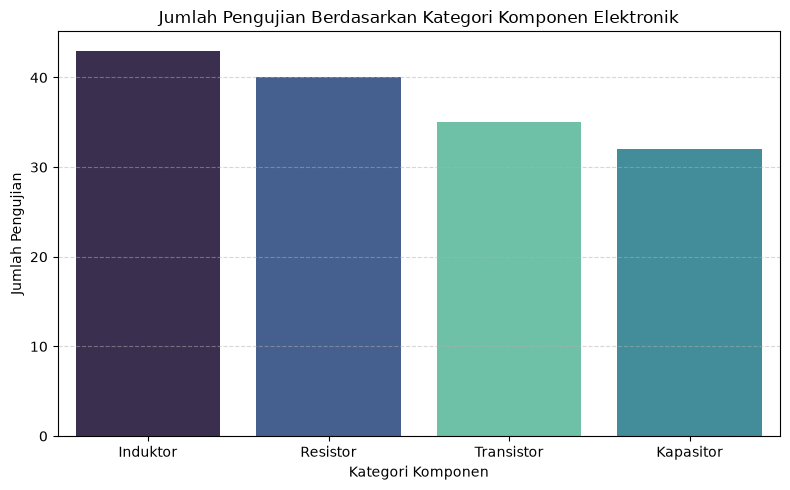

In [3]:
# Visualisasi 1: Barplot Frekuensi Komponen yang Diuji
plt.figure(figsize=(8, 5))
order_kategori = df['Kategori_Komponen'].value_counts().index
sns.countplot(data=df, x='Kategori_Komponen', order=order_kategori, palette='mako', hue='Kategori_Komponen', legend=False)
plt.title('Jumlah Pengujian Berdasarkan Kategori Komponen Elektronik')
plt.xlabel('Kategori Komponen')
plt.ylabel('Jumlah Pengujian')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Insight Visualisasi 1:

Grafik batang ini menampilkan distribusi volume pengujian sampel di laboratorium berdasarkan jenis komponen elektronik (Resistor, Kapasitor, Induktor, dan Transistor). Data ini membantu memantau fokus alokasi beban pengujian mutu pada jenis komponen tertentu.

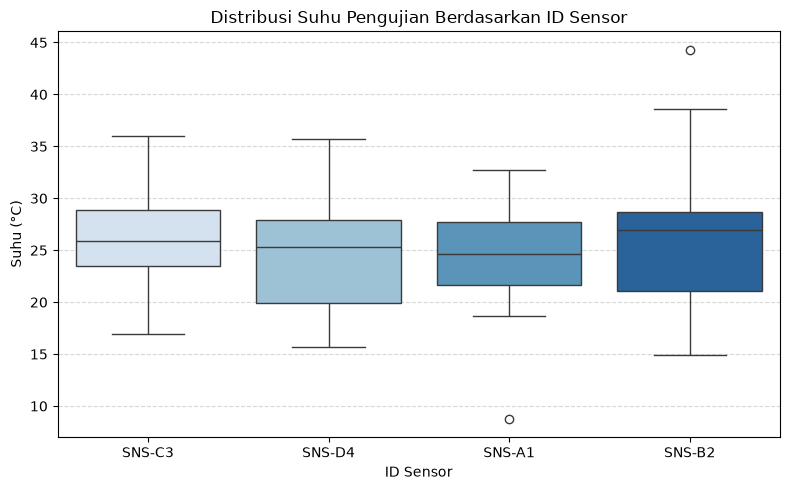

In [4]:
# Visualisasi 2: Boxplot Suhu Pengujian Berdasarkan ID Sensor
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='ID_Sensor', y='Suhu_Celcius', palette='Blues', hue='ID_Sensor', legend=False)
plt.title('Distribusi Suhu Pengujian Berdasarkan ID Sensor')
plt.xlabel('ID Sensor')
plt.ylabel('Suhu (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Insight Visualisasi 2:

Visualisasi boxplot menunjukkan variasi dan stabilitas pembacaan suhu operasional pada masing-masing unit sensor (SNS-A1 hingga SNS-D4). Hal ini membantu tim teknis mengidentifikasi apakah terdapat unit sensor tertentu yang mengalami bias kalibrasi atau fluktuasi suhu ekstrem saat digunakan.

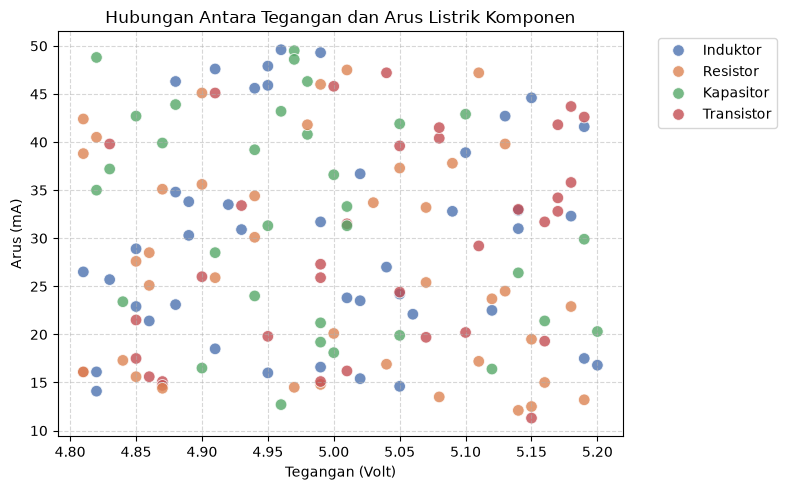

In [5]:
# Visualisasi 3: Scatter Plot Tegangan Volt vs Arus mA
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Tegangan_Volt', y='Arus_mA', hue='Kategori_Komponen', palette='deep', s=70, alpha=0.8)
plt.title('Hubungan Antara Tegangan dan Arus Listrik Komponen')
plt.xlabel('Tegangan (Volt)')
plt.ylabel('Arus (mA)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight Visualisasi 3:

Scatter plot ini menggambarkan distribusi hubungan antara besarnya tegangan listrik (Volt) dan arus (mA) pada tiap kategori komponen elektronik. Sebaran titik ini penting untuk menganalisis karakteristik kelistrikan serta mendeteksi adanya respons sampel komponen yang menyimpang dari standar operasional.